In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Q1 - Outliers in Machine Learning

In [2]:
# Create df with normal-distributed values
np.random.seed(9009)
df = pd.DataFrame({'Age':np.random.normal(50, 15, 100)})
df.head()


,Age
0,59.573964
1,58.952745
2,57.771322
3,67.936495
4,41.108436


In [3]:
# Adding extreme values

df.loc[np.random.choice(df.index, 5),'Age'] = [200,150,-10,170,300]

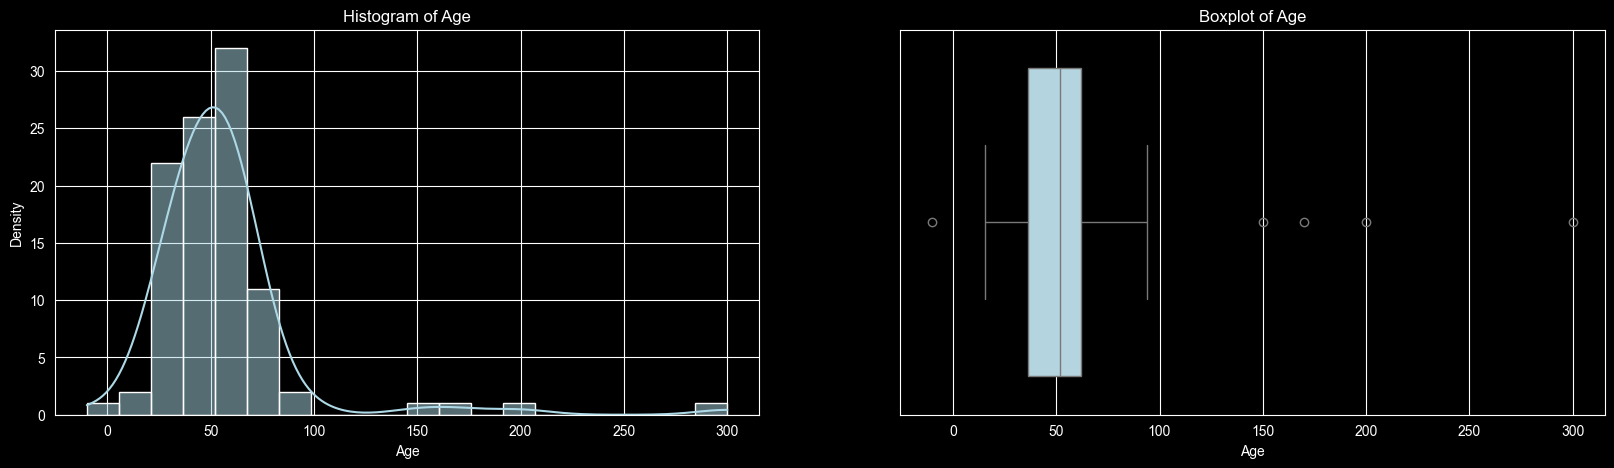

In [6]:
# Histogram & boxplot

fig, axes = plt.subplots(1,2,figsize=(20,5))

sns.histplot(data=df,ax=axes[0], x='Age', color='lightblue',kde=True)
axes[0].set_title('Histogram of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')

sns.boxplot(data=df,ax=axes[1],x='Age', color='lightblue')
axes[1].set_title('Boxplot of Age')
axes[1].set_xlabel('Age')

plt.show()


#### Q2 - Outlier Detection and Removal using the Z-score Method

In [11]:
# Mean & Std

mean = df['Age'].mean()
std = df['Age'].std()

print(f'Mean: {mean:.2f}')
print(f'Std: {std:.2f}')

Mean: 55.48
Std: 36.70


In [13]:
# Z-score

df['z_score'] = (df['Age']-mean) / std
df

,Age,z_score
0,59.573964,0.111668
1,58.952745,0.094744
2,57.771322,0.062557
3,67.936495,0.339500
4,41.108436,-0.391413
...,...,...
95,47.666550,-0.212741
96,59.875935,0.119895
97,26.958836,-0.776909
98,59.701086,0.115132


In [36]:
# Remove outliers

threshold = 3
print(f'Outliers: {df[df['z_score'].abs() > threshold]}')
df_clean = df[df['z_score'].abs() <= threshold].copy()
df_clean.drop(columns=['z_score'], inplace=True)
print(f'Cleaned Data: \n{df_clean}')

Outliers:       Age   z_score
26  300.0  6.661917
32  170.0  3.120153
61  200.0  3.937483
Cleaned Data: 
          Age
0   59.573964
1   58.952745
2   57.771322
3   67.936495
4   41.108436
..        ...
95  47.666550
96  59.875935
97  26.958836
98  59.701086
99  26.851250

[97 rows x 1 columns]


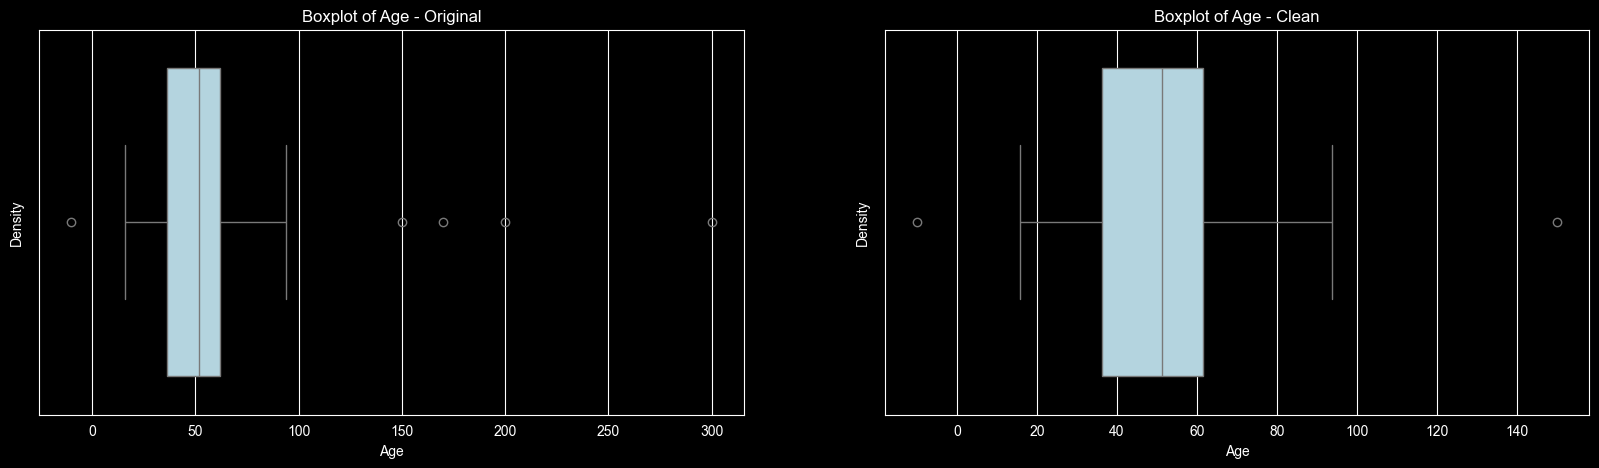

As you can see this method removed some extreme outliers but it failed to remove some of the outliers.


In [38]:
# Clean vs original

fig, axes = plt.subplots(1,2,figsize=(20,5))

sns.boxplot(data=df, ax=axes[0], x='Age', color='lightblue')
axes[0].set_title('Boxplot of Age - Original')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')

sns.boxplot(data=df_clean, ax=axes[1], x='Age', color='lightblue')
axes[1].set_title('Boxplot of Age - Clean')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

plt.show()

print('As you can see this method removed some extreme outliers but it failed to remove some of the outliers.')
